In [1]:
import os
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.backends.backend_pdf import PdfPages

import numpy as np

from pybaselines import Baseline, utils

import lmfit as lm
from lmfit import Model, Parameters, Parameter, report_fit, minimize, Minimizer

from scipy.signal import find_peaks

from assign_peaks import *

In [2]:
def process_files(txt_folder, num_files=960):
    files = [f for f in os.listdir(txt_folder) if not f.startswith('.')]
    files = files[:num_files]  # Vybereme pouze prvních 100 souborů
    df_tim, df_amp = [], []

    for f in files:
        print(f)
        txt_file = os.path.join(txt_folder, f)
        df_tim.append(pd.read_csv(txt_file, header=5, sep=",", usecols=[0]))
        df_amp.append(pd.read_csv(txt_file, header=5, sep=",", usecols=[1]))

    df_all_tim = pd.concat(df_tim, ignore_index=True, axis=1)
    df_all_amp = pd.concat(df_amp, ignore_index=True, axis=1)

    df_all_tim.to_csv('time.csv', sep=',')
    df_all_amp.to_csv('ampl.csv', sep=',')

    df_mean_tim = df_all_tim.mean(axis=1)
    df_mean_tim.to_csv('time_aver.txt', sep=',')
    df_mean_amp = df_all_amp.mean(axis=1)
    df_mean_amp.to_csv('ampl_aver.txt', sep=',')

    with open('averaged.txt', 'w') as f:
        pd.concat([df_mean_tim, df_mean_amp], axis=1).to_csv(f, sep=',')

    print('!Averaging finished!')

# Použití
txt_folder = '2fexp5'
process_files(txt_folder)

C2_2025-03-11_PS_K2_5proCO2_00000.txt
C2_2025-03-11_PS_K2_5proCO2_00001.txt
C2_2025-03-11_PS_K2_5proCO2_00002.txt
C2_2025-03-11_PS_K2_5proCO2_00003.txt
C2_2025-03-11_PS_K2_5proCO2_00004.txt
C2_2025-03-11_PS_K2_5proCO2_00005.txt
C2_2025-03-11_PS_K2_5proCO2_00006.txt
C2_2025-03-11_PS_K2_5proCO2_00007.txt
C2_2025-03-11_PS_K2_5proCO2_00008.txt
C2_2025-03-11_PS_K2_5proCO2_00009.txt
C2_2025-03-11_PS_K2_5proCO2_00010.txt
C2_2025-03-11_PS_K2_5proCO2_00011.txt
C2_2025-03-11_PS_K2_5proCO2_00012.txt
C2_2025-03-11_PS_K2_5proCO2_00013.txt
C2_2025-03-11_PS_K2_5proCO2_00014.txt
C2_2025-03-11_PS_K2_5proCO2_00015.txt
C2_2025-03-11_PS_K2_5proCO2_00016.txt
C2_2025-03-11_PS_K2_5proCO2_00017.txt
C2_2025-03-11_PS_K2_5proCO2_00018.txt
C2_2025-03-11_PS_K2_5proCO2_00019.txt
C2_2025-03-11_PS_K2_5proCO2_00020.txt
C2_2025-03-11_PS_K2_5proCO2_00021.txt
C2_2025-03-11_PS_K2_5proCO2_00022.txt
C2_2025-03-11_PS_K2_5proCO2_00023.txt
C2_2025-03-11_PS_K2_5proCO2_00024.txt
C2_2025-03-11_PS_K2_5proCO2_00025.txt
C2_2025-03-1

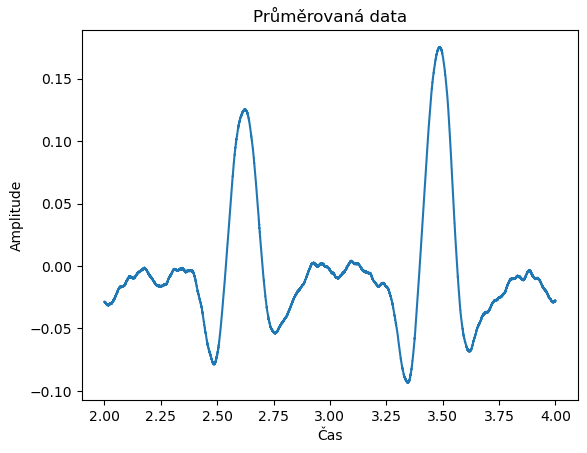

In [3]:
# Načtení průměrovaných dat ze souborů
df_mean_tim = pd.read_csv('time_aver.txt', sep=',', header= None, skiprows=1)
df_mean_amp = pd.read_csv('ampl_aver.txt', sep=',', header= None,  skiprows=1)
# Převod na numpy array
xs = df_mean_tim[1].to_numpy()
ys = df_mean_amp[1].to_numpy()

# Posun hodnot na x-ové ose o 2 sekundy
xs = xs + 2

# Vykreslení grafu
plt.plot(xs, ys)
plt.xlabel('Čas')
plt.ylabel('Amplitude')
plt.title('Průměrovaná data')
plt.show()

InputFile = 'averaged.txt'

In [4]:
#Number_of_Samples_per_Second
print(len(xs))
SpS = int(len(xs)/np.max(xs))
print("!Sampling rate of the datases is " + str(SpS) + " Samples/s!" )

10000
!Sampling rate of the datases is 2500 Samples/s!


In [5]:
Out1 = PdfPages('out2f_exp.pdf')
Out2 = PdfPages('out2f_fit.pdf')

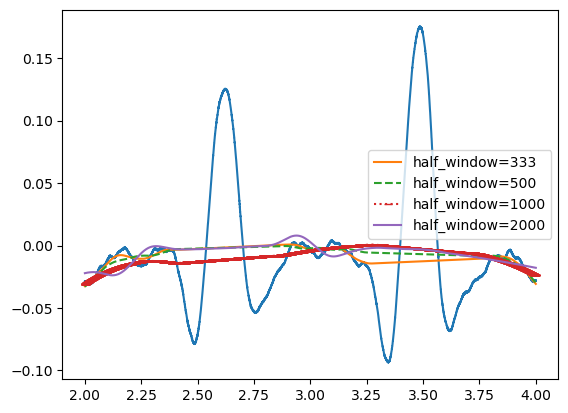

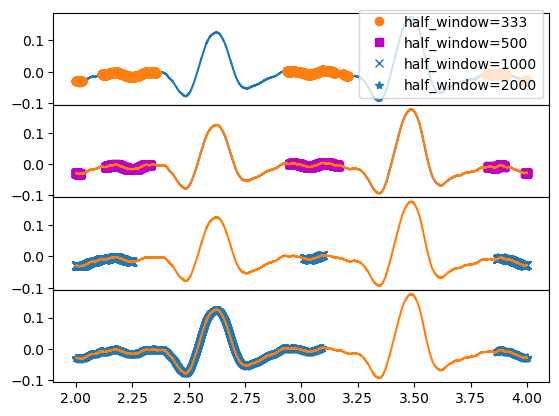

In [6]:
baseline_fitter = Baseline(x_data=xs)

#std_distribution(data, x_data=None, half_window=None, interp_half_window=5,
#                     fill_half_window=3, num_std=1.1, smooth_half_window=None,
#                     weights=None, **pad_kwargs):

half_window_1 = 333
half_window_2 = 500
half_window_3 = 1000
half_window_4 = 2000


fit_1, params_1 = baseline_fitter.std_distribution(ys, half_window_1, smooth_half_window=None)
fit_2, params_2 = baseline_fitter.std_distribution(ys, half_window_2, smooth_half_window=None)
fit_3, params_3 = baseline_fitter.std_distribution(ys, half_window_3, smooth_half_window=None)
fit_4, params_4 = baseline_fitter.std_distribution(ys, half_window_4, smooth_half_window=None)


plt.plot(xs, ys)
plt.plot(xs, fit_1, label=f'half_window={half_window_1}')
plt.plot(xs, fit_2, '--', label=f'half_window={half_window_2}')
plt.plot(xs, fit_3, '_:',  label=f'half_window={half_window_3}')
plt.plot(xs, fit_4, '-', label=f'half_window={half_window_4}')
plt.legend()

mask_1 = params_1['mask']
mask_2 = params_2['mask']
mask_3 = params_3['mask']
mask_4 = params_4['mask']

_, (ax1, ax2, ax3, ax4) = plt.subplots(4, sharex=True, gridspec_kw={'hspace': 0})
ax1.plot(xs, ys)
patch_1 = ax1.plot(xs[mask_1], ys[mask_1], 'o')[0]
ax2.plot(xs, ys)
patch_2 = ax2.plot(xs[mask_2], ys[mask_2], 'ms')[0]
ax2.plot(xs, ys)
patch_3 = ax3.plot(xs[mask_3], ys[mask_3], 'x')[0]
ax3.plot(xs, ys)
patch_4 = ax4.plot(xs[mask_4], ys[mask_4], '*')[0]
ax4.plot(xs, ys)

ax1.legend((patch_1, patch_2, patch_3, patch_4), (f'half_window={half_window_1}', f'half_window={half_window_2}', f'half_window={half_window_3}', f'half_window={half_window_4}'))

plt.show()

In [7]:
bkg=fit_2

#ys=ys-bkg

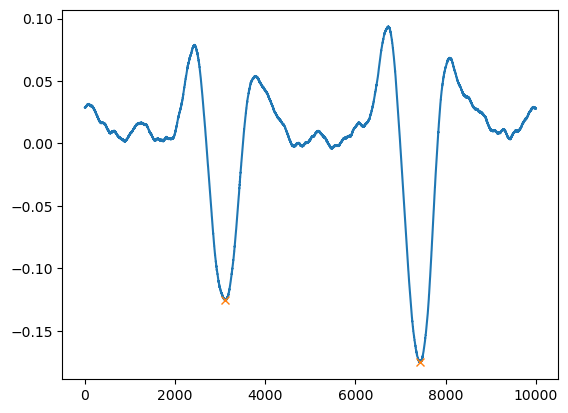

In [8]:
valleys, _ = find_peaks(ys, height=0.05, distance=500, width=250)
np.diff(valleys)
plt.plot(-ys)
plt.plot(valleys, -ys[valleys], "x")
plt.show()

xval = xs[valleys]
yval = ys[valleys]

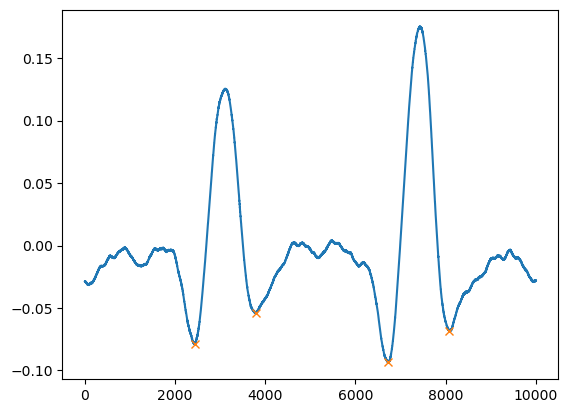

In [9]:
peaks, _ = find_peaks(-ys, height=0.03, distance=750, width=250)
np.diff(peaks)
plt.plot(ys)
plt.plot(peaks, ys[peaks], "x")
plt.show()

xpik = xs[peaks]
ypik = ys[peaks]

In [10]:
#vytvoreni pole objektu peaku
peak_objects = AssignPeaks(xpik, xval, ypik, yval)
numpeak = len(peak_objects)
#overeni delek poli minim a maxim
VerifyPeaksLength(xpik, xval, peak_objects)
#vypsat
SavePeakSpectra(peak_objects, xs, ys, InputFile, 2)

Peaks matched/consistent definition!
Total number of peaks identified in 2f-WMS signal is: 2
Peak1 centered at: 2.620600000000006(left minimum: 2.4869999999999997; right minimum: 2.7576000000000094)
Peak2 centered at: 3.486599999999984(left minimum: 3.3458000000000183; right minimum: 3.616599999999978)


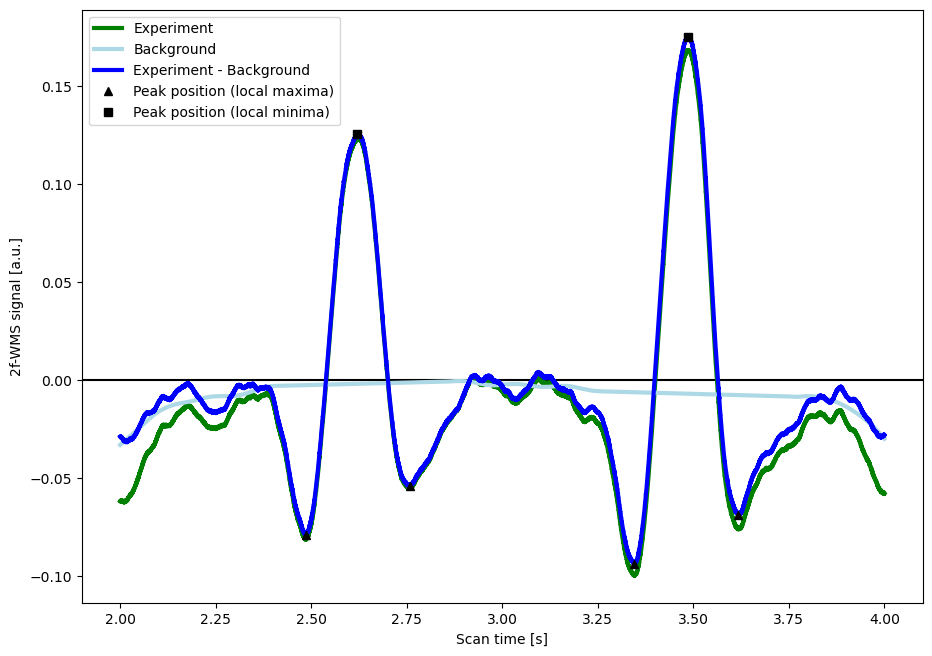

In [11]:
plt.figure(2) 
plt.axhline(0, color='black') 
line1, = plt.plot(xs, ys+bkg, color='green', linewidth=3, label='Experiment') 
line2, = plt.plot(xs, bkg, color='lightblue', linewidth=3, label='Background') 
line3, = plt.plot(xs, ys, color='blue', linewidth=3, label='Experiment - Background') 
point1, = plt.plot(xpik, ypik, 'k^', linewidth=3, label='Peak position (local maxima)') 
point2, = plt.plot(xval, yval, 'ks', linewidth=3, label='Peak position (local minima)') 
plt.legend(handler_map={line1: HandlerLine2D(numpoints=1)}) 
plt.xlabel(r"Scan time [s]") 
plt.ylabel(r"2f-WMS signal [a.u.]") 
plt.tight_layout() 
a4 = plt.gcf() 
a4.set_size_inches([10,7]) 
a4.savefig(Out1, format='pdf') 
plt.show() 
Out1.close()

In [12]:
def lorentzianA(xs, a0, a1, a2):
    return a0/(np.pi*a2*(1+((xs-a1)/a2)**2))

def D2lorentzianA(xs, a0, a1, a2):
    return -2*a0*a2*(a2**2-3*(a1-xs)**2)/(np.pi*(a2**2+(a1-xs)**2)**3)

def gaussianA(xs, a0, a1, a2):
    sigma = a2/np.sqrt(2*np.log(2))
    return a0/(sigma*np.sqrt(2*np.pi))*np.exp(-(xs-a1)**2/(2*sigma**2))

def D2gaussianA(xs, a0, a1, a2):
    sigma = np.sqrt(2*np.log(2))*a2
    poly2 = ((xs-a1)**2-sigma**2)/sigma**4
    return poly2*a0/(sigma*np.sqrt(2*np.pi))*np.exp(-(xs-a1)**2/(2*sigma**2))

In [13]:
result=[None]*numpeak
par=[None]*numpeak
resdata=[None]*numpeak
ofst=[None]*numpeak
minner=[None]*numpeak
res2ult=[None]*numpeak
fin2ual=[None]*numpeak
res2data=[None]*numpeak
par2am=[None]*numpeak
gabor2=[None]*numpeak
gabor4=[None]*numpeak
gabor6=[None]*numpeak
gabor8=[None]*numpeak
gabor10=[None]*numpeak

[[Fit Statistics]]
    # fitting method   = differential_evolution
    # function evals   = 1823
    # data points      = 4286
    # variables        = 3
    chi-square         = 0.79294071
    reduced chi-square = 1.8514e-04
    Akaike info crit   = -36832.6672
    Bayesian info crit = -36813.5778
    R-squared          = 0.91927144
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    a0: -6.2084e-04 (init = 0.1255028)
    a1:  2.62016661 (init = 2.1948)
    a2:  0.13838041 (init = 0.1714)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 215
    # data points      = 4286
    # variables        = 14
    chi-square         = 0.06260264
    reduced chi-square = 1.4654e-05
    Akaike info crit   = -47692.5686
    Bayesian 

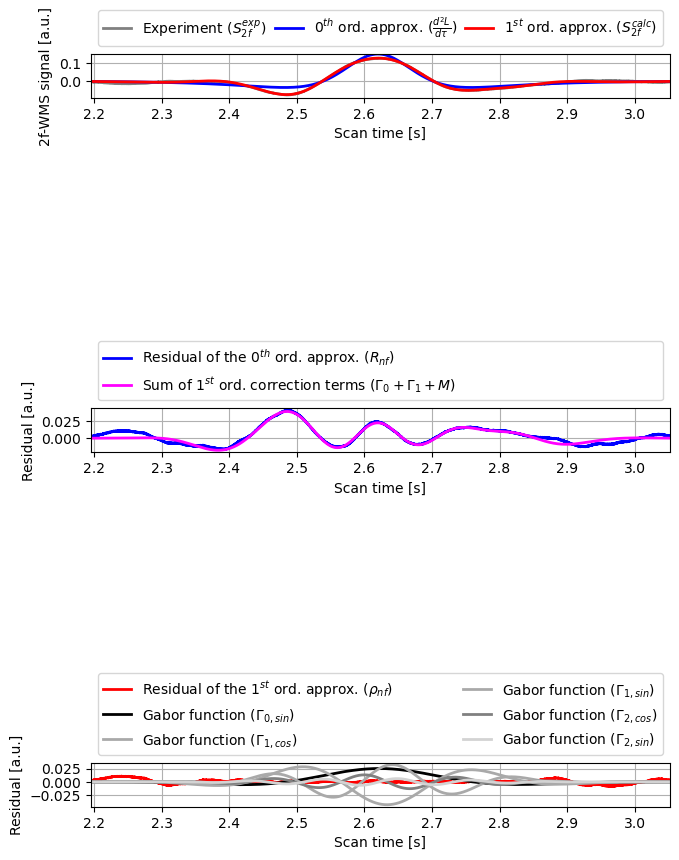

[[Fit Statistics]]
    # fitting method   = differential_evolution
    # function evals   = 1750
    # data points      = 4287
    # variables        = 3
    chi-square         = 0.81291581
    reduced chi-square = 1.8976e-04
    Akaike info crit   = -36735.6057
    Bayesian info crit = -36716.5157
    R-squared          = 0.95377089
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    a0: -8.9279e-04 (init = 0.1753581)
    a1:  3.48350978 (init = 3.0536)
    a2:  0.14145392 (init = 0.17144)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 275
    # data points      = 4287
    # variables        = 14
    chi-square         = 0.06197058
    reduced chi-square = 1.4503e-05
    Akaike info crit   = -47748.2055
    Bayesian

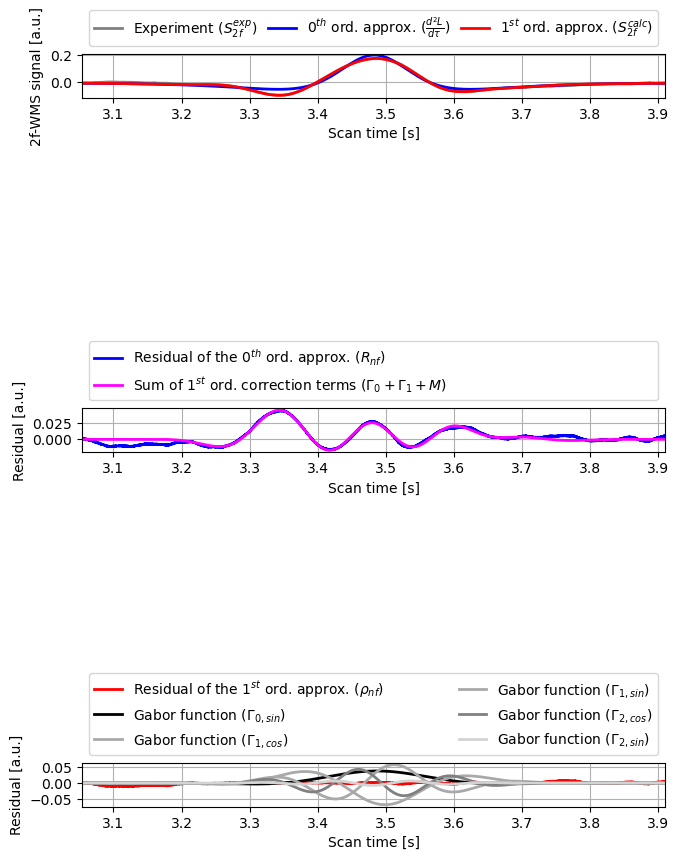

In [14]:
for i in range(1,numpeak+1):
    j=i-1
    
    InputFilePeaks = InputFile.replace(".txt", '_Peak') + str(i) + '.txt'
    Dataset = np.loadtxt(InputFilePeaks, skiprows= 0 + 1 + 2 + 3 + 4 , delimiter=',')
    x = Dataset[:, 0]
    y = Dataset[:, 1]

    Out3i = PdfPages('out_peakfit' + str(i) + '.pdf')
    
    params = lm.Parameters()
    params.add('a0', value=np.maximum(np.abs(np.amax(-y)),np.abs(np.amin(-y))), min=10*np.amin(-y), max=10*np.amax(-y))
    params.add('a1', value=np.amin(x)-(np.amax(x)-np.amin(x))/2, min=np.amin(x), max=np.amax(x))
    params.add('a2', value=(np.amax(x)-np.amin(x))/5, min=(np.amax(x)-np.amin(x))/10, max=(np.amax(x)-np.amin(x))/2)

    #model = lm.Model(D2gaussianA)
    model = lm.Model(D2lorentzianA)
     #result[j] = model.fit(y, params, x=x, method='leastsq')
    result[j] = model.fit(y, params, xs=x, method='differential_evolution')
    
    lm.report_fit(result[j])

    par[j] = result[j].best_values
   
    resdata[j] = result[j].residual
    
    #ofst[j] = np.mean(resdata[j])
    ofst[j] = 0
    
    def residual(params, x, resdata):
        "Gabor polynomial"
        params['a0']= Parameter(name = 'a0', value = par[j]['a0'] , vary = False)
        params['a1']= Parameter(name = 'a1', value = par[j]['a1'] , vary = False)
        params['a2']= Parameter(name = 'a2', value = par[j]['a2'] , vary = False)

        off = params['off']
        params['off']= Parameter(name = 'off', value = ofst[j] , vary = False)
        k2 = params['k2']
        k4 = params['k4']
        k6 = params['k6']

        k8 = params['k8']
        fi8 = params['fi8']
        
        k10 = params['k10']
        fi10 = params['fi10']

        fi6 = params['fi6']
        fi4 = params['fi4']
        fi2 = params['fi2']
        
        a0 = params['a0']
        a1 = params['a1']
        a2 = params['a2']

        w = params['w']

        sigma = a2/np.sqrt(2*np.log(2))
        gabor10 = np.cos(2*np.pi*(5/2)*(x-a1)/(2*a2)+fi10)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor8 = np.cos(2*np.pi*(4/2)*(x-a1)/(2*a2)+fi8)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor6 = np.sin(2*np.pi*(3/2)*(x-a1)/(2*a2)+fi6)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor4 = np.cos(2*np.pi*(2/2)*(x-a1)/(2*a2)+fi4)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor2 = np.sin(2*np.pi*(1/2)*(x-a1)/(2*a2)+fi2)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        
        return off + k10*gabor10 + k8*gabor8 + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
        #return off + k8*gabor8 + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
        #return off + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
    
        # create a set of Parameters
    
    params.add('off', min=-par[j]['a0'], max=par[j]['a0'], vary = False)
    params.add('k6', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k4', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k2', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k8', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k10', value=1.0, min=-50, max=50.0, vary = True)
    params.add('fi10', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi8', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi6', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi4', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi2', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('w', value=1.33, min= 1/3, max=5/3, vary = True)

       
    # do fit, here with leastsq model
    minner[j] = Minimizer(residual, params, fcn_args=(x, resdata[j]))
    res2ult[j] = minner[j].minimize(method = 'leastsq')
    # res2ult[j] = minner[j].minimize(method = 'differential_evolution')

    par2am[j] = res2ult[j].params
    #par2am[j].pretty_print()

    offj=par2am[j]['off'].value
    a0j=par2am[j]['a0'].value
    a1j=par2am[j]['a1'].value
    a2j=par2am[j]['a2'].value
    k6j=par2am[j]['k6'].value
    k4j=par2am[j]['k4'].value
    k2j=par2am[j]['k2'].value
    k8j=par2am[j]['k8'].value
    k10j=par2am[j]['k10'].value
    fi10j=par2am[j]['fi10'].value
    fi8j=par2am[j]['fi8'].value
    fi6j=par2am[j]['fi6'].value
    fi4j=par2am[j]['fi4'].value
    fi2j=par2am[j]['fi2'].value
    sigmaj = a2j/np.sqrt(2*np.log(2))
    wj=par2am[j]['w'].value

    gabor10[j] = np.sin(5*np.pi*(x-a1j)/(2*a2j)+fi10j)*k10j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor8[j] = np.cos(4*np.pi*(x-a1j)/(2*a2j)+fi8j)*k8j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor6[j] = np.sin(3*np.pi*(x-a1j)/(2*a2j)+fi6j)*k6j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor4[j] = np.cos(2*np.pi*(x-a1j)/(2*a2j)+fi4j)*k4j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor2[j] = np.sin(1*np.pi*(x-a1j)/(2*a2j)+fi2j)*k2j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))

    res2data[j] = res2ult[j].residual
    
    # calculate final result
    fin2ual[j] = resdata[j] + res2data[j]
    
    # write error report
    report_fit(res2ult[j])
    
    # write signal curve after Gabor fitting into csv file{x, result[j].best_fit-fin2ual[j]}
    # Create a DataFrame directly for each index j
    df = pd.DataFrame({'x': x, 'result_minus_fin2ual_plus_offset': result[j].best_fit + fin2ual[j] + offj})
    # Write DataFrame to CSV file, naming it based on index j
    goutput_filename = f'goutput_{j+1}.csv'
    df.to_csv(goutput_filename, index=False)
    print(f'Data written to {goutput_filename} successfully.')
    
    fig2 = plt.figure(2)
    
    ax1=plt.subplot(311)
    line2, = plt.plot(x, y, 'grey', linewidth=2, label= r'Experiment ($S_{2f}^{exp}$)')
    line3, = plt.plot(x, result[j].best_fit, 'blue', linewidth=2, label= r'$0^{th}$ ord. approx. ($\frac{d^{2}L}{d\tau}$)')
    line3f, = plt.plot(x, result[j].best_fit+fin2ual[j], 'red', linewidth=2, label= r'$1^{st}$ ord. approx. ($S_{2f}^{calc}$)')
    plt.legend(handler_map={line1: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,1.02,1,0.2), loc="lower left", mode="expand", ncol=3)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"2f-WMS signal [a.u.]")
    plt.axis([1.0*np.amin(x), 1.0*np.amax(x), 1.2*np.amin(y), 1.2*np.amax(y),])
    plt.grid(True)

    ax2=plt.subplot(312, sharex=ax1)
    line4, = plt.plot(x, -result[j].residual, 'blue',linewidth=2, label=r'Residual of the $0^{th}$ ord. approx. ($R_{nf}$)')
    line5, = plt.plot(x, -fin2ual[j], 'magenta', linewidth=2, label=r'Sum of $1^{st}$ ord. correction terms ($\Gamma_0 + \Gamma_1 + M$)')
    plt.legend(handler_map={line4: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,1.02,1,0.2), loc="lower left", mode="expand", ncol=1)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"Residual [a.u.]")
    #plt.axis([1.0*np.amin(x), 1.0*np.amax(x), -1.5*np.amax(result[j].residual), -2.5*np.amin(result[j].residual),])
    plt.grid(True)
    
    ax3=plt.subplot(313, sharex=ax1)
    line6, = plt.plot(x, res2ult[j].residual, 'red',linewidth=2, label=r'Residual of the $1^{st}$ ord. approx. ($\rho_{nf}$)')
    line7, = plt.plot(x, -gabor2[j], 'black',linewidth=2, label= r'Gabor function ($\Gamma_{0,sin}$)')
    line8, = plt.plot(x, -gabor4[j], 'darkgray',linewidth=2, label= r'Gabor function ($\Gamma_{1,cos}$)')
    line9, = plt.plot(x, -gabor6[j], 'darkgrey',linewidth=2, label=r'Gabor function ($\Gamma_{1,sin}$)')
    line10, = plt.plot(x, -gabor8[j], 'grey',linewidth=2, label=r'Gabor function ($\Gamma_{2,cos}$)')
    line11, = plt.plot(x, -gabor10[j], 'lightgrey',linewidth=2, label=r'Gabor function ($\Gamma_{2,sin}$)')
    #line11, = plt.plot(x, -gabor2[j]-gabor4[j]-gabor6[j]-gabor8[j], 'm:',linewidth=4)
    plt.legend(handler_map={line6: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,1.02,1,0.2), loc="lower left", mode="expand", ncol=2)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"Residual [a.u.]")
    #plt.axis([1.0*np.amin(x), 1.0*np.amax(x), 2.0*offj-1.5*np.amax(result[j].residual), 2.0*offj-2.5*np.amin(result[j].residual),])
    plt.grid(True)
    
    plt.tight_layout()
    a4 = plt.gcf()
    a4.set_size_inches([7,10])
    a4.savefig(Out2, format='pdf')
    a4.savefig(Out3i, format='pdf')
    plt.show()

    Out3i.close()
    
Out2.close()

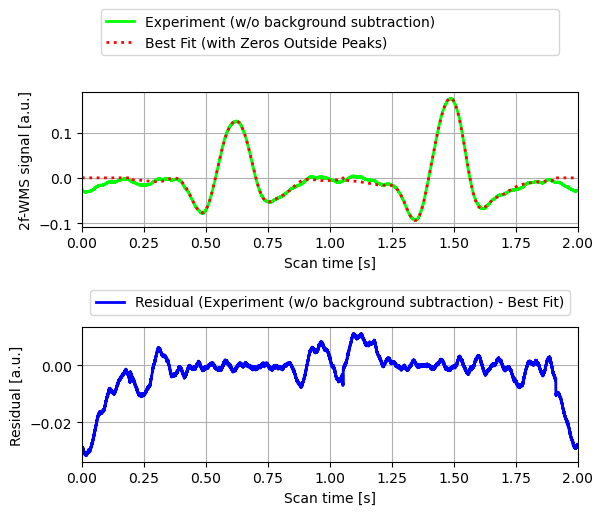

In [15]:
# g1_x, g1_y for peak g1 around 37
OutputFile1 = 'goutput_1.csv'
Dataset1 = np.loadtxt(OutputFile1, skiprows=1, delimiter=',')
g1_x = Dataset1[:, 0]
g1_y = Dataset1[:, 1]

# g2_x, g2_y for the second peak (you can specify the correct file or arrays)
OutputFile2 = 'goutput_2.csv'
Dataset2 = np.loadtxt(OutputFile2, skiprows=1, delimiter=',')
g2_x = Dataset2[:, 0]
g2_y = Dataset2[:, 1]

# Create new y array with zeros outside the range of the two peaks
goutput_y = np.zeros_like(xs)

# Set y-values for the first peak
goutput_y[(xs >= np.min(g1_x)) & (xs <= np.max(g1_x))] = g1_y[(g1_x >= np.min(g1_x)) & (g1_x <= np.max(g1_x))]

# Set y-values for the second peak
goutput_y[(xs >= np.min(g2_x)) & (xs <= np.max(g2_x))] = g2_y[(g2_x >= np.min(g2_x)) & (g2_x <= np.max(g2_x))]

# Save the new array to a CSV file if needed
goutput = np.column_stack((xs, goutput_y))
np.savetxt('goutput.csv', goutput, delimiter=',', header='x,y', comments='')


import matplotlib.pyplot as plt

fig3 = plt.figure(2)

ax1 = plt.subplot(211)
#plt.plot(xs, ys+bkg, 'grey', linewidth=2, label='Experiment ($S_{2f}^{exp}$)')
plt.plot(xs-2, ys, 'lime', linewidth=2,  label='Experiment (w/o background subtraction)                           ')
plt.plot(xs-2, goutput_y, 'red', linestyle="dotted", linewidth=2, label='Best Fit (with Zeros Outside Peaks)')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.67), ncol=1)
plt.xlabel("Scan time [s]")
plt.ylabel("2f-WMS signal [a.u.]")
plt.xlim([0, 2])
plt.grid(True)

ax2 = plt.subplot(212)
plt.plot(xs-2, ys-goutput_y, 'blue', linewidth=2, label='Residual (Experiment (w/o background subtraction) - Best Fit)')
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.33), ncol=1)
plt.xlabel("Scan time [s]")
plt.ylabel("Residual [a.u.]")
plt.xlim([0, 2])
plt.grid(True)

# Adjust vertical space between subplots
fig3.subplots_adjust(hspace=0.75)

plt.show()

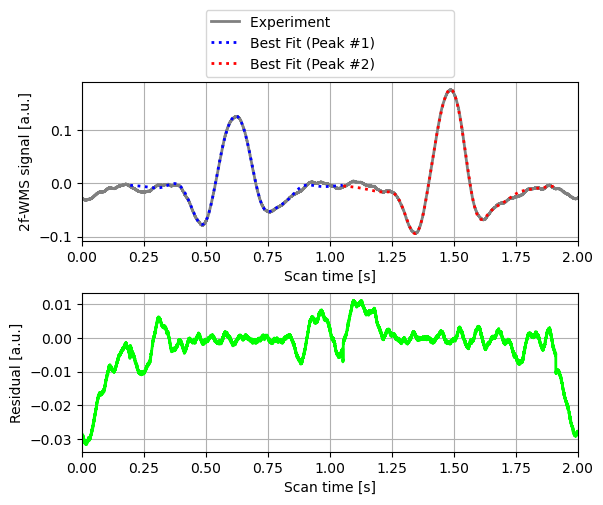

Peak 1:
  - Výška od nuly (h2f): 0.1255028076539102
  - Amplituda (a2f): 0.1919680768062396
Peak 2:
  - Výška od nuly (h2f): 0.1753580547420967
  - Amplituda (a2f): 0.25644126785856913


In [16]:
fig4 = plt.figure(2)

ax1 = plt.subplot(211)
plt.plot(xs-2, ys, 'grey', linewidth=2,  label='Experiment                           ')
plt.plot(g1_x-2, g1_y, 'blue', linestyle="dotted", linewidth=2, label='Best Fit (Peak #1)')
plt.plot(g2_x-2, g2_y, 'red', linestyle="dotted", linewidth=2, label='Best Fit (Peak #2)')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.5), ncol=1)
plt.xlabel("Scan time [s]")
plt.ylabel("2f-WMS signal [a.u.]")
plt.xlim([0, 2])
plt.grid(True)

ax2 = plt.subplot(212)
plt.plot(xs-2, ys-goutput_y, 'lime', linewidth=2)
#plt.plot(xs, ys-goutput_y, 'blue', linewidth=2, label='Residual (Experiment (w/o background subtraction) - Best Fit)')
#ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.33), ncol=1)
plt.xlabel("Scan time [s]")
plt.ylabel("Residual [a.u.]")
plt.xlim([0, 2])
plt.grid(True)

# Adjust vertical space between subplots
fig4.subplots_adjust(hspace=0.33)

plt.show()

h2f_values = []  # Výšky od nuly
a2f_values = []  # Amplitudy

# Pro každý peak v poli peak_objects
for peak in peak_objects:
    h2f = peak.s2_max  # Výška od nuly
    a2f = peak.s2_ampl  # Amplituda

    h2f_values.append(h2f)
    a2f_values.append(a2f)

# Výpis výsledků
for i, (h2f, a2f) in enumerate(zip(h2f_values, a2f_values)):
    print(f"Peak {i+1}:")
    print(f"  - Výška od nuly (h2f): {h2f}")
    print(f"  - Amplituda (a2f): {a2f}")